### Import Libraries


In [7]:
# Data Manipulation

import pandas as pd
import numpy as np

# Data Visualization

import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor

# Evaluation Metrics

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings('ignore')

In [2]:
day = pd.read_csv("day.csv")
hour = pd.read_csv("hour.csv")

In [3]:
day.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [4]:
day.tail()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
726,727,2012-12-27,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247,1867,2114
727,728,2012-12-28,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644,2451,3095
728,729,2012-12-29,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159,1182,1341
729,730,2012-12-30,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364,1432,1796
730,731,2012-12-31,1,1,12,0,1,1,2,0.215833,0.223487,0.577500,0.154846,439,2290,2729


In [5]:
hour.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [6]:
hour.tail()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
17374,17375,2012-12-31,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,11,108,119
17375,17376,2012-12-31,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,8,81,89
17376,17377,2012-12-31,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,7,83,90
17377,17378,2012-12-31,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,13,48,61
17378,17379,2012-12-31,1,1,12,23,0,1,1,1,0.26,0.2727,0.65,0.1343,12,37,49


- Use day.csv dataset
- 1.Faster EDA
- 2.Faster model training

The dataset contains daily bike rental information along with weather, seasonal, and environmental variables.

The target variable is cnt, which represents the total number of rented bikes.

In [8]:
# Dataset Shape

day.shape

(731, 16)

The shape function provides the total number of rows and columns in the dataset.

Rows represent daily observations and columns represent features.

In [9]:
# Dataset Information

day.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


The dataset contains both integer and float variables.

No major datatype issues are visible.

In [10]:
# Statistical Summary

day.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


The summary statistics provide information regarding distribution, spread, minimum, maximum, and average values of the variables.

In [12]:
# Missing Value Analysis

day.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Check whether any missing values exist in the dataset.

If no missing values are present, no imputation is required.

In [13]:
# Duplicate Analysis

day.duplicated().sum()

0

In [15]:
# Data Cleaning

day.drop(['instant','dteday'],axis=1,inplace=True)

- Here, do not use casual,registered as input features.
- cnt = casual + registered.

In [16]:
day.drop(['casual','registered'],axis=1,inplace=True)

### Exploratory Data Analysis (EDA)
#### Target Variable Analysis

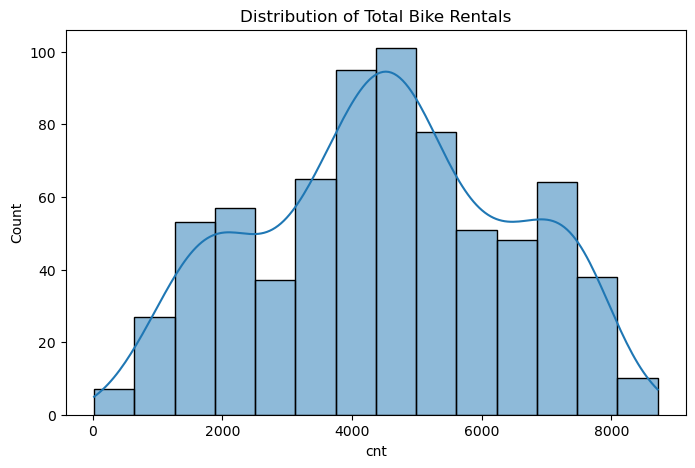

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(day['cnt'],kde=True)
plt.title("Distribution of Total Bike Rentals")
plt.show()

1. The distribution shows the daily bike rental demand.
2. Most rental counts are concentrated around the middle range.
3. Understanding the target distribution helps select appropriate regression models.

#### Season vs Bike rentals

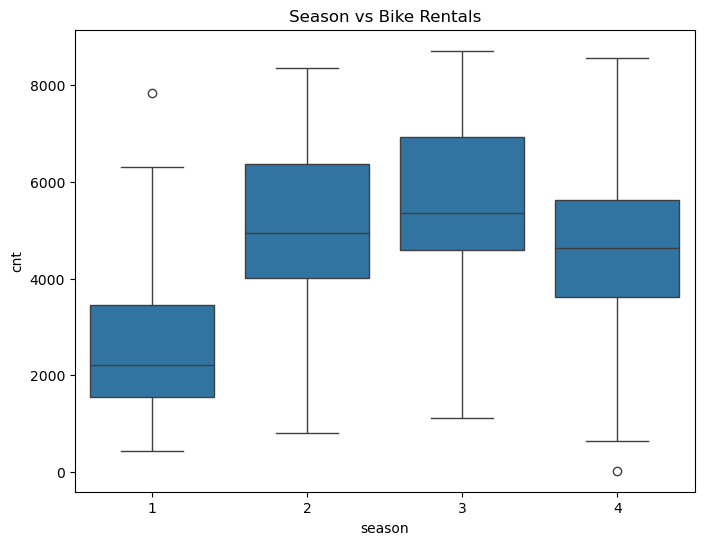

In [20]:
plt.figure(figsize=(8,6))
sns.boxplot(x='season',
            y='cnt',
            data=day)
plt.title('Season vs Bike Rentals')
plt.show()

1. Bike rental demand varies across seasons.
2. Summer and Fall generally show higher rental counts.
3. Weather conditions significantly influence bike usage.

#### Year vs Bike Rentals

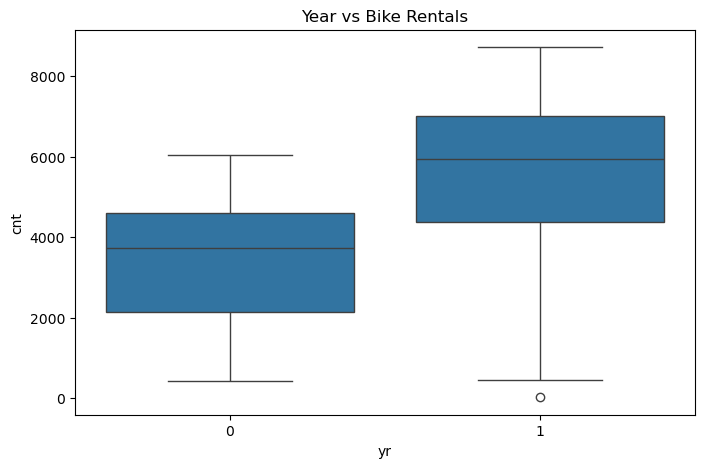

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(x ='yr',
            y='cnt',
            data = day
           )
plt.title("Year vs Bike Rentals")
plt.show()

1. Rental demand increased in 2012 compared to 2011.
2. This indicates growing popularity of the bike-sharing service.

#### Month vs Bike Rentals

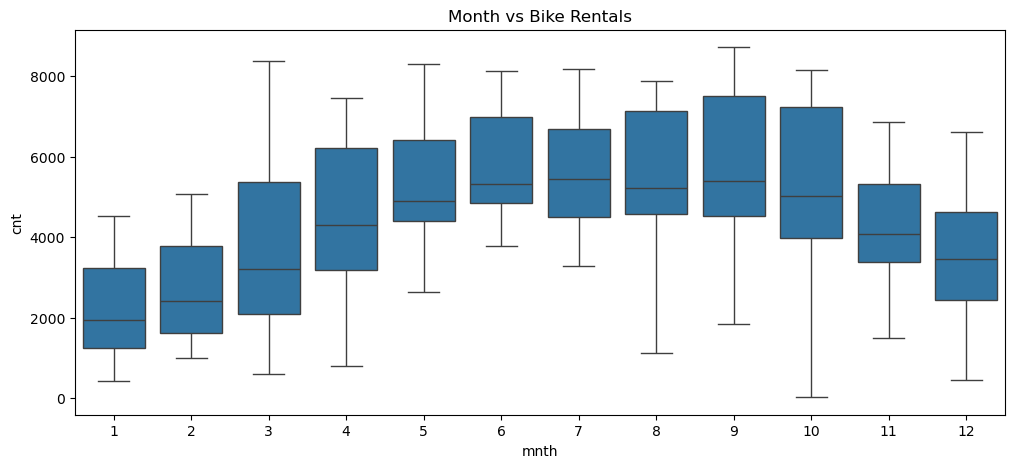

In [23]:
plt.figure(figsize=(12,5))
sns.boxplot(x= 'mnth',
            y='cnt',
            data=day
           )
plt.title("Month vs Bike Rentals")
plt.show()

1. Demand fluctuates across months.
2. Warmer months generally have higher bike rental activity.
3. Winter months show lower demand.

#### Wheather Situation vs Bike Rentals

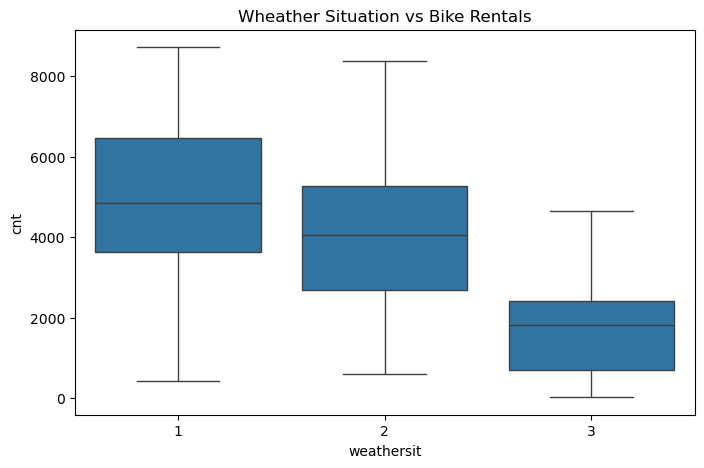

In [24]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x = 'weathersit',
    y = 'cnt',
    data =day
)
plt.title("Wheather Situation vs Bike Rentals")
plt.show()

1. Clear weather results in higher rental demand.
2. Poor weather conditions significantly reduce bike usage.
3. Weather is one of the strongest influencing factors.

#### Temperature vs Bike Rentals

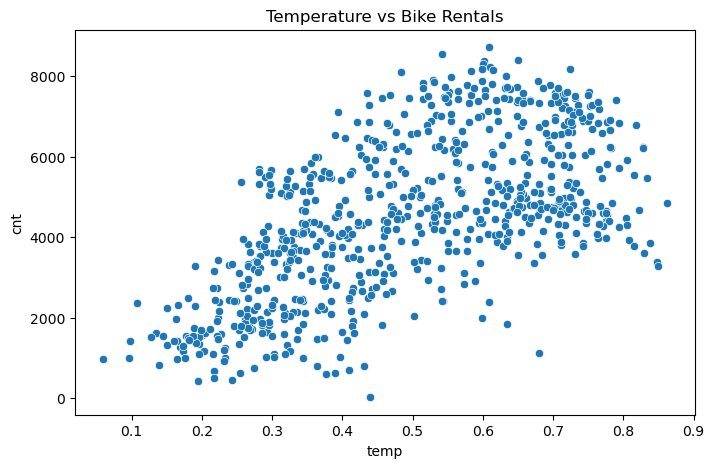

In [26]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x = 'temp',
    y = 'cnt',
    data =day
)
plt.title("Temperature vs Bike Rentals")
plt.show()

1. Bike rentals generally increase as temperature rises.
2. People prefer riding bikes during comfortable weather conditions.
3. Temperature has a positive relationship with demand.

#### Humdity vs Bike Rentals

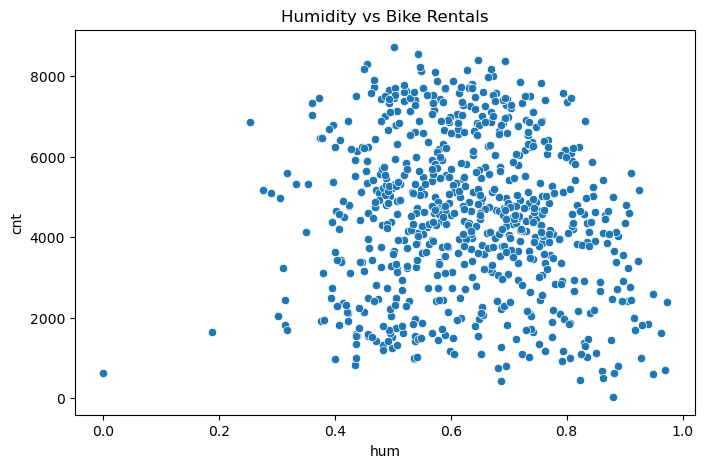

In [29]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x = 'hum',
    y = 'cnt',
    data =day
)
plt.title("Humidity vs Bike Rentals")
plt.show()

1. Higher humidity tends to reduce bike rentals.
2. Excessive humidity may make outdoor activities less comfortable.

#### Windspeed vs Bike Rentals

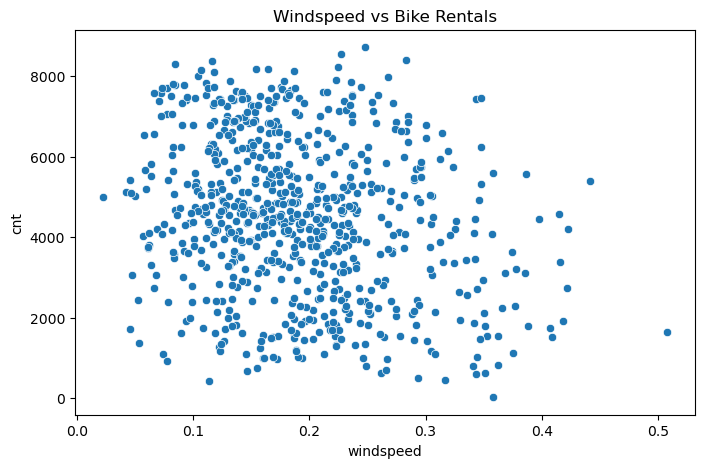

In [31]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='windspeed',
    y='cnt',
    data=day
)

plt.title('Windspeed vs Bike Rentals')

plt.show()

1. Higher wind speeds may discourage bike usage.
2. Demand generally decreases during windy conditions.

#### Working day vs Bike Rentals

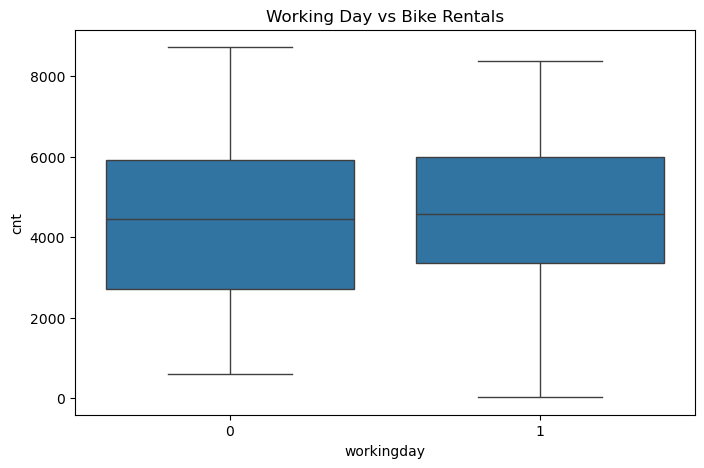

In [33]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='workingday',
    y='cnt',
    data=day
)

plt.title('Working Day vs Bike Rentals')

plt.show()

1. Rental patterns differ between working and non-working days.
2. Commuting behavior influences bike demand.

#### Correlation Heatmap

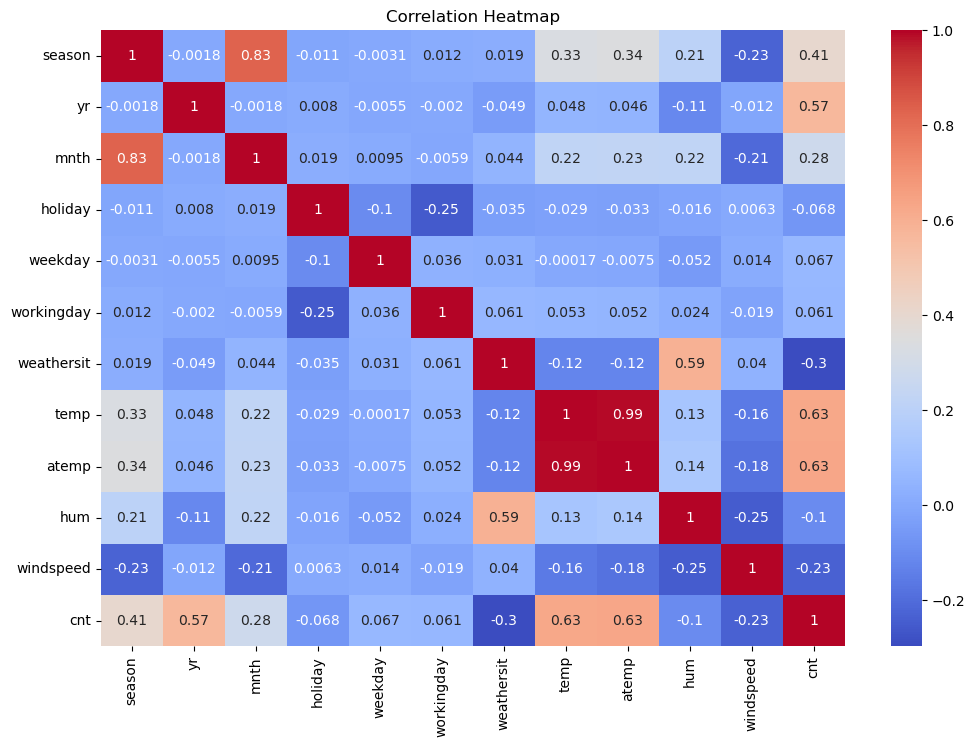

In [34]:
plt.figure(figsize=(12,8))

sns.heatmap(
    day.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

1. Temperature shows a strong positive correlation with bike rentals.
2. Year also positively influences demand.
3. Humidity and adverse weather conditions negatively affect rentals.
4. Strongly correlated variables can significantly influence prediction accuracy.

EDA Summary

1. Bike rentals increase during favorable weather conditions.
2. Summer and Fall seasons show higher rental demand.
3. Temperature positively affects bike rentals.
4. Humidity and windspeed negatively affect demand.
5. Rental demand increased from 2011 to 2012.
6. Weather and seasonal variables are important predictors of bike demand.

### Feature Selection

In [35]:
X = day.drop('cnt',axis=1)
y = day['cnt']

In [36]:
print(X.shape)
print(y.shape)

(731, 11)
(731,)


X contains all independent variables.

y contains the target variable (total bike rentals).

The goal is to predict the rental count using environmental and seasonal features.

### Train-Test Split

In [41]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [42]:
print(X_train.shape)
print(X_test.shape)

(584, 11)
(147, 11)


80% of data is used for training.

20% is used for testing.

This allows evaluation on unseen observations.

### Feature Scaling

- Linear Regression performs better with scaled features

In [43]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Feature scaling standardizes the variables and improves model stability.

### Linear Regression

In [44]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train_scaled,y_train)
pred_lr = lr.predict(X_test_scaled)

#### Evaluation

In [45]:
from sklearn.metrics import (
mean_absolute_error,
mean_squared_error,
r2_score)
print("R2 Score",r2_score(y_test,pred_lr))
print("MAE",mean_absolute_error(y_test,pred_lr))
print("MSE",mean_squared_error(y_test,pred_lr))
print("RMSE",np.sqrt(mean_squared_error(y_test,pred_lr)))

R2 Score 0.8276670090367212
MAE 617.3930656443374
MSE 691035.0082022651
RMSE 831.2851545662686


### Decision Tree Regressor

In [46]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train,y_train)
pred_dt = dt.predict(X_test)

#### Evaluation

In [47]:
print("R2 Score",r2_score(y_test,pred_dt))
print("MAE",mean_absolute_error(y_test,pred_dt))
print("MSE",mean_squared_error(y_test,pred_dt))
print("RMSE",np.sqrt(mean_squared_error(y_test,pred_dt)))

R2 Score 0.7585417237651239
MAE 662.8027210884354
MSE 968219.2653061225
RMSE 983.9813338199676


### Random Forest Regressor

In [48]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train,y_train)
pred_rf = rf.predict(X_test)

#### Evaluation

In [49]:
print("R2 Score",r2_score(y_test,pred_rf))
print("MAE",mean_absolute_error(y_test,pred_rf))
print("MSE",mean_squared_error(y_test,pred_rf))
print("RMSE",np.sqrt(mean_squared_error(y_test,pred_rf)))

R2 Score 0.8856707218333267
MAE 429.958299319728
MSE 458446.9475870749
RMSE 677.0871048743101


### Model Comparison

In [52]:
results = pd.DataFrame({
    'Model':[
        'Linear Regression',
        'Decison Tree',
        'Random Forest'
    ],
    'R2 Score':[
        r2_score(y_test,pred_lr),
         r2_score(y_test,pred_dt),
         r2_score(y_test,pred_rf)
    ]
})
results.sort_values(
    by = 'R2 Score',
    ascending = False
)

,Model,R2 Score
2,Random Forest,0.885671
0,Linear Regression,0.827667
1,Decison Tree,0.758542


#### Visualization

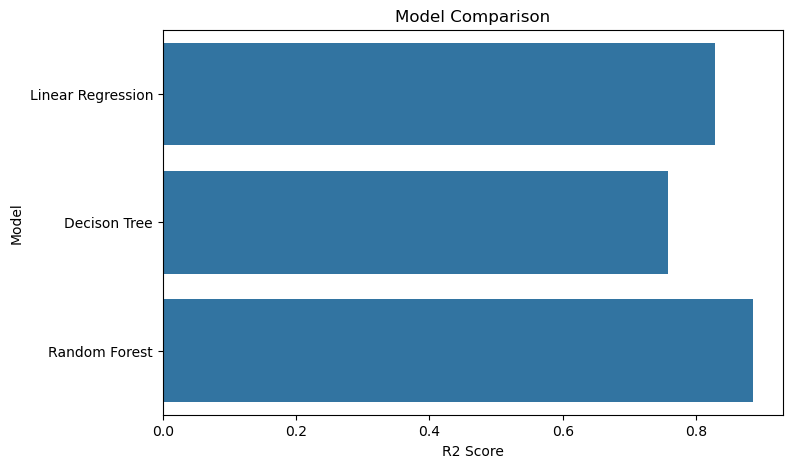

In [54]:
plt.figure(figsize=(8,5))
sns.barplot(
    x = 'R2 Score',
    y = 'Model',
    data = results
)
plt.title("Model Comparison")
plt.show()

### Model Comparison Report

Three regression models were developed and evaluated for predicting bike rental demand.

The models were compared using the R² Score metric.

Results:

1. Random Forest Regressor achieved an R² Score of 0.88.
2. Linear Regression achieved an R² Score of 0.82.
3. Decision Tree Regressor achieved an R² Score of 0.75.

Among all models, Random Forest Regressor demonstrated the highest predictive performance and was selected as the final model for deployment.

### Feature Importance

In [55]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
7,temp,0.351733
1,yr,0.279657
8,atemp,0.155569
9,hum,0.059340
0,season,0.052566
10,windspeed,0.032912
2,mnth,0.026553
6,weathersit,0.018494
4,weekday,0.015780
5,workingday,0.004390


#### Visualization

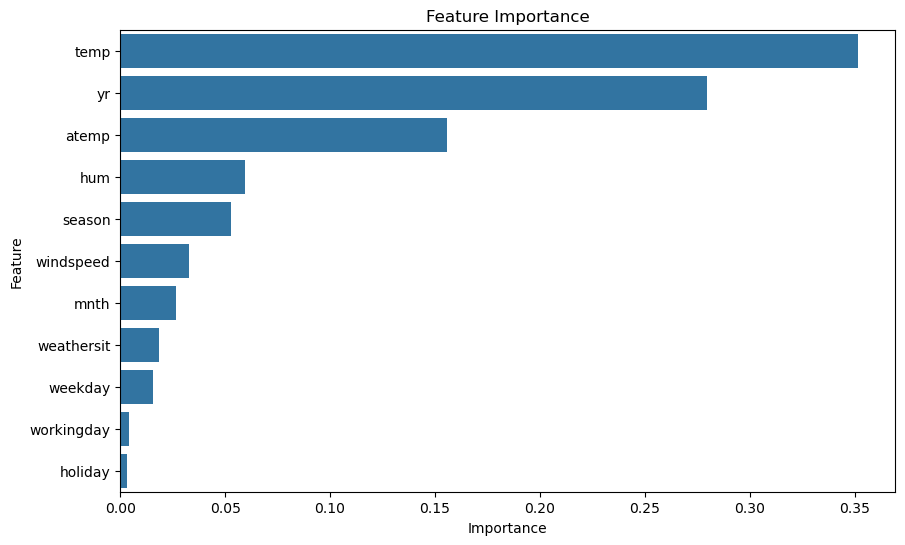

In [56]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title('Feature Importance')

plt.show()

#### Expected Important Features

- temp
- atemp
- yr
- season
- weathersit
- hum

### Business Interpretation

Temperature:

Temperature has a strong positive influence on bike rentals.
People prefer renting bikes during comfortable weather conditions.

Weather Situation:

Clear weather significantly increases bike rental demand.
Rainy or snowy conditions reduce rentals.

Season:

Seasonal variations directly affect bike usage.
Summer and Fall generally experience higher demand.

Year:

Rental demand increased from 2011 to 2012, indicating growing adoption of the bike-sharing service.


### Business Impact Report

1. Demand Forecasting

The model helps predict future bike rental demand accurately.

2. Resource Planning

The company can allocate bikes efficiently across locations.

3. Operational Efficiency

Bike shortages and excess inventory can be minimized.

4. Improved Customer Experience

Adequate bike availability increases customer satisfaction.

5. Revenue Optimization

Better planning leads to higher utilization and profitability.

### Challenges Faced

1. Understanding the influence of weather and seasonal factors on bike demand.

2. Selecting appropriate features for prediction.

3. Choosing the best regression model.

4. Avoiding data leakage from casual and registered user counts.

5. Interpreting model outputs for business decisions.

### Techniques Used

1. Performed Exploratory Data Analysis (EDA).

2. Removed unnecessary columns and leakage variables.

3. Compared multiple regression algorithms.

4. Evaluated models using R² Score.

5. Used feature importance analysis for interpretation.

### Conclusion

A complete data analysis and machine learning solution was developed to predict daily bike rental demand.

Exploratory Data Analysis revealed that weather conditions, temperature, season, and year significantly influence bike rentals.

Three regression models were trained and evaluated: Linear Regression, Decision Tree Regressor, and Random Forest Regressor.

Among all models, Random Forest Regressor achieved the highest R² Score of 0.88 and was selected as the final model.

The developed solution can help bike-sharing companies forecast demand, optimize operations, and improve customer satisfaction.